# 03 - Filtrado

Notebook reservado para la Fase 3: diseño y prueba de filtros en frecuencia.

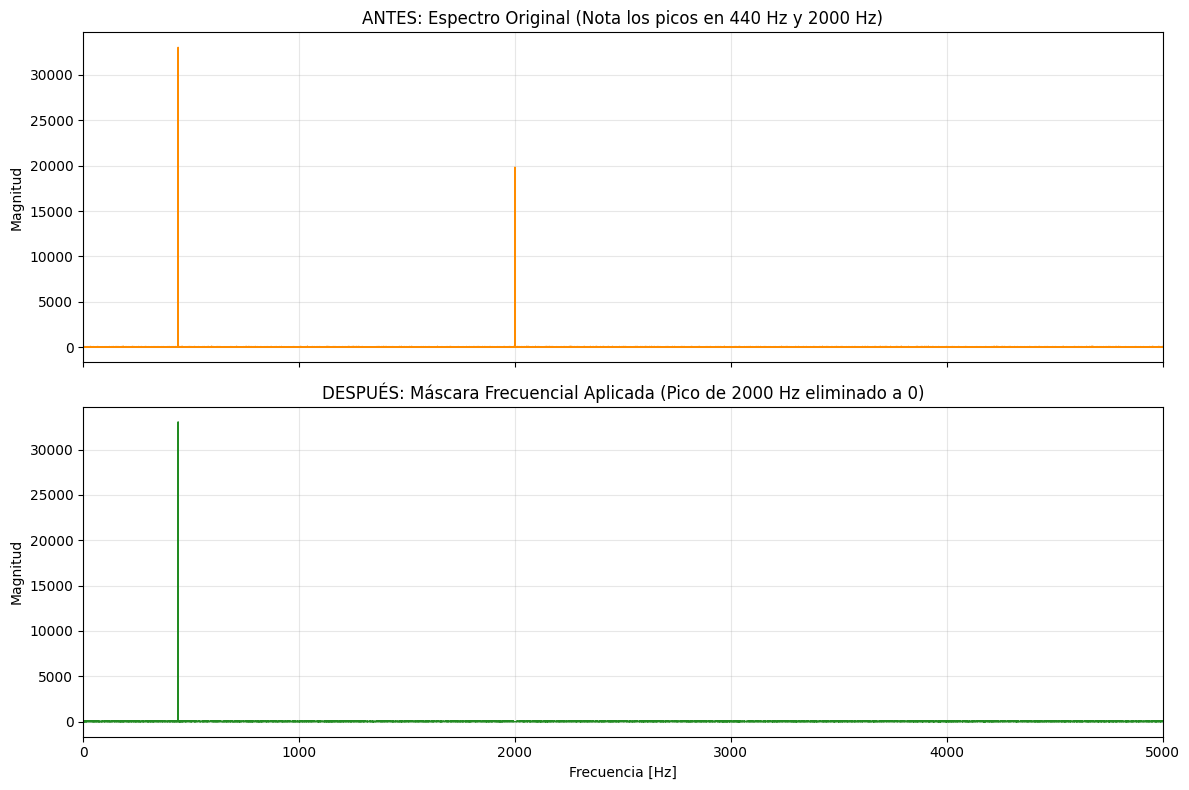

In [4]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq

# 1. Conectamos tu arquitectura modular
sys.path.append("..")
from src.audio_loader import load_audio
from src.filters import apply_notch_mask

# 2. Cargamos el audio sintético (con los picos de 440 Hz y 2000 Hz)
AUDIO_PATH = Path("../data/raw/PruebaAN1.wav")
senal_ruidosa, sample_rate = load_audio(AUDIO_PATH)

# 3. FASE 2: Transformada
N = len(senal_ruidosa)
espectro_ruidoso = fft(senal_ruidosa)
frecuencias = fftfreq(N, 1 / sample_rate) # Reconstruimos el eje X (Frecuencias)

# 4. FASE 3: Diseño de Máscara (El filtro)
# Usamos 2000 Hz como ruido de prueba — es audible en cualquier parlante.
# bandwidth_hz=10 para asegurarnos de capturar el pico completo.
espectro_limpio = apply_notch_mask(espectro_ruidoso, center_hz=2000.0, bandwidth_hz=10.0, sample_rate=sample_rate)

# --- INICIO DE LA VISUALIZACIÓN ---
# Para graficar, solo tomamos la mitad positiva del espectro
mitad = N // 2
freqs_plot = frecuencias[:mitad]
mag_ruido = np.abs(espectro_ruidoso[:mitad])
mag_limpio = np.abs(espectro_limpio[:mitad])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Gráfica Original
ax1.plot(freqs_plot, mag_ruido, color='darkorange', linewidth=1)
ax1.set_title("ANTES: Espectro Original (Nota los picos en 440 Hz y 2000 Hz)")
ax1.set_ylabel("Magnitud")
ax1.set_xlim(0, 5000) # Zoom para ver ambos picos
ax1.grid(True, alpha=0.3)

# Gráfica con la Máscara
ax2.plot(freqs_plot, mag_limpio, color='forestgreen', linewidth=1)
ax2.set_title("DESPUÉS: Máscara Frecuencial Aplicada (Pico de 2000 Hz eliminado a 0)")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Magnitud")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# --- FIN DE LA VISUALIZACIÓN ---

# 5. FASE 4: Reconstrucción
senal_limpia = np.real(ifft(espectro_limpio))

## Paso 1: Aplicar el filtro Notch para eliminar el ruido de 2000 Hz

Ya sabemos que nuestra señal tiene dos componentes: la nota musical (440 Hz) y el silbido de prueba (2000 Hz). Ahora vamos a eliminar solo el silbido, sin tocar la nota.

Para eso usamos un **filtro Notch** (también llamado filtro de banda eliminada). Su funcionamiento es muy directo:

1. Tomamos el espectro que nos dio la FFT.
2. Identificamos el rango de frecuencias que queremos borrar (alrededor de 2000 Hz).
3. Ponemos esas frecuencias en **cero** — como si las borráramos con corrector.
4. Aplicamos la **IFFT** para regresar al dominio temporal y obtener el audio limpio.

La gráfica mostrará el espectro **antes** y **después** del filtro. El pico de 2000 Hz debería desaparecer completamente, mientras que el de 440 Hz permanece intacto.

> **¿Por qué 2000 Hz y no 60 Hz?**
> El zumbido eléctrico real es de 60 Hz, pero esa frecuencia es tan grave que la mayoría de parlantes de laptop y audífonos básicos no la reproducen físicamente. Con 2000 Hz la diferencia es claramente audible en cualquier dispositivo, lo que nos permite verificar con los propios oídos que el filtro funciona.

In [5]:
import soundfile as sf

# 1. Guardamos el audio original (con zumbido) para tenerlo a la mano
ruta_ruido = Path("../data/processed/Prueba1_audio_con_zumbido.wav")
sf.write(ruta_ruido, senal_ruidosa, sample_rate)

# 2. Guardamos nuestro audio filtrado matemáticamente
ruta_limpio = Path("../data/processed/Prueba1_audio_limpio_fft.wav")
sf.write(ruta_limpio, senal_limpia, sample_rate)

print(f"Audios exportados en la carpeta 'data/processed/'.")
print("¡Ve a tu explorador de archivos, ponte audífonos y escucha la diferencia!")

Audios exportados en la carpeta 'data/processed/'.
¡Ve a tu explorador de archivos, ponte audífonos y escucha la diferencia!


## Paso 2: Exportar los audios para escuchar la diferencia

Guardamos ambas versiones del audio en archivos `.wav`:
- **`1_audio_con_zumbido.wav`** → el audio original con el ruido de 60 Hz.
- **`2_audio_limpio_fft.wav`** → el audio después del filtro, sin zumbido.

Esto nos permite hacer la prueba más intuitiva de todas: ponerse audífonos y escuchar con los propios oídos si el zumbido desapareció.